# Section 1.2 — Data in practice

This notebook contains all the code from [Section 1.2 Data in practice](https://minireference.com/static/excerpts/noBSstats/noBSstats_ch01_DATA.pdf#page=34) of the **No Bullshit Guide to Statistics**.

#### Notebook setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Figures setup
import seaborn as sns
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"font.family": "serif",
        "font.serif": ["Palatino", "DejaVu Serif", "serif"],
        "figure.figsize": (5, 2)},
)
%config InlineBackend.figure_format = "retina"

In [3]:
# simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

In [4]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory present and ready.


## Getting started with JupyterLab

### Download and install JupyterLab Desktop
Follow instructions in the [Python tutorial](./python_tutorial.ipynb) to install JupyterLab Desktop on your computer.

### Download the `noBSstats` notebooks and datasets

Go to URL https://github.com/minireference/noBSstats and use the Code dropdown button to download the ZIP archive of the entire repository.

![](./attachments/data/repo-download-zip.png)


After downloading the ZIP archive,
double-click on the file to extract its contents,
and move the resulting folder `noBSstats` to a location on your computer
where you normally keep your documents.

The ZIP archive includes all the datasets and computational notebooks for the book.
Use the **File browser** pane on the right 
to navigate to the location where you saved the `noBSstats` folder
and explore the subfolders `datasets`, `notebooks`, `exercises`, `tutorials`, etc.

### Datasets for the book

The `datasets` folder contains all the datasets used in examples and exercises throughout the book.

| id | filename | relative path | url |
| --- | --- | --- | --- |
| 0 | players.csv | datasets/players.csv | https://noBSstats.com/datasets/players.csv |
| 1 | apples.csv | datasets/apples.csv | https://noBSstats.com/datasets/apples.csv |
| 2 | eprices.csv | datasets/eprices.csv | https://noBSstats.com/datasets/eprices.csv |
| 3 | students.csv | datasets/students.csv | https://noBSstats.com/datasets/students.csv |
| 4 | kombucha.csv | datasets/kombucha.csv | https://noBSstats.com/datasets/kombucha.csv |
| 4p | kombuchapop.csv | datasets/kombuchapop.csv | https://noBSstats.com/datasets/kombuchapop.csv |
| 5 | doctors.csv | datasets/doctors.csv | https://noBSstats.com/datasets/doctors.csv |
| 6 | visitors.csv | datasets/visitors.csv | https://noBSstats.com/datasets/visitors.csv |
| D | minimal.csv | datasets/minimal.csv | https://noBSstats.com/datasets/minimal.csv |


### Interactive notebooks for each section


The `notebooks` folder contains the jupyter notebooks associated with each section of the book,
similar to the one you're currently looking at.

| section | notebook name |
| --- | --- |
| Section 1.1 | 11_data_collection.ipynb |
| Section 1.2 | 12_data_in_practice.ipynb |
| Section 1.3 | 13_descriptive_statistics.ipynb |
| Section 2.1 | 21_discrete_random_vars.ipynb |
| Section 2.2 | 22_multiple_random_vars.ipynb |
| Section 2.3 | 23_inventory_discrete_dists.ipynb |
| Section 2.4 | 24_continuous_random_vars.ipynb |
| Section 2.5 | 25_multiple_continuous_random_vars.ipynb |
| Section 2.5 | 26_inventory_continuous_dists.ipynb |
| Section 2.6 | 27_simulations.ipynb |
| Section 2.7 | 28_random_samples.ipynb |
| Section 3.1 | 31_estimators.ipynb |
| Section 3.2 | 32_confidence_intervals.ipynb |
| Section 3.3 | 33_intro_to_NHST.ipynb |
| Section 3.4 | 34_analytical_approx.ipynb |
| Section 3.5 | 35_two_sample_tests.ipynb |
| Section 3.6 | 36_design.ipynb |
| Section 3.7 | 37_inventory_stats_tests.ipynb |
| Section 4.1 | 41_introduction_to_LMs.ipynb |

### Exercises notebooks


The `exercises` folder contains starter notebooks for the exercises in each section.

| section | notebook name |
| --- | --- |
| Section 1.2 | exercises_12_practical_data.ipynb |
| Section 1.3 | exercises_13_descr_stats.ipynb |
| Section 2.1 | exercises_21_discrete_RVs.ipynb |
| Section 3.1 | exercises_31_estimtors.ipynb |
| Section 3.2 | exercises_32_confidence_intervals.ipynb |
| Section 3.3 | exercises_33_intro_to_NHST.ipynb |
| Section 3.5 | exercises_35_two_sample_tests.ipynb |


## Data management with Pandas

The first step is to import the Pandas library.
We'll follow the standard convention of importing the `pandas` module under the alias `pd`.

In [5]:
import pandas as pd

### Loading datasets

#### Players dataset

Consider the data file `players.csv` located in the `datasets` directory.
The file extension `.csv` tells us the file contains text data formatted as Comma-Separated Values (CSV).
We can use the command `%pycat` to print the raw contents of the this file.

In [6]:
%pycat datasets/players.csv

username,country,age,ezlvl,time,points,finished
mary,us,38,0,124.94,418,0
jane,ca,21,0,331.64,1149,1
emil,fr,52,1,324.61,1321,1
ivan,ca,50,1,39.51,226,0
hasan,tr,26,1,253.19,815,0
jordan,us,45,0,28.49,206,0
sanjay,ca,27,1,350.0,1401,1
lena,uk,23,0,408.76,1745,1
shuo,cn,24,1,194.77,1043,0
r0byn,us,59,0,255.55,1102,0
anna,pl,18,0,303.66,1209,1
joro,bg,22,1,381.97,1491,1


We see the file contains 13 lines of text, and each line contains—as promised by the `.csv` file extension—values separated by commas.
The first line in the data file is called the "header" and contains the names of the variable names.

We can create a the data frame object from the players dataset located at `datasets/players.csv`
by calling the function `pd.read_csv`.

In [7]:
players = pd.read_csv("datasets/players.csv")
players

,username,country,age,ezlvl,time,points,finished
0,mary,us,38,0,124.94,418,0
1,jane,ca,21,0,331.64,1149,1
2,emil,fr,52,1,324.61,1321,1
3,ivan,ca,50,1,39.51,226,0
4,hasan,tr,26,1,253.19,815,0
5,jordan,us,45,0,28.49,206,0
6,sanjay,ca,27,1,350.00,1401,1
7,lena,uk,23,0,408.76,1745,1
8,shuo,cn,24,1,194.77,1043,0
9,r0byn,us,59,0,255.55,1102,0


### Data frame properties

What type of object is `players` ?

In [8]:
type(players)

pandas.DataFrame

The `players` data frame object has a bunch of useful properties (attributes)
and functions (methods) "attached" to it,
which we can access using the dot syntax.

#### The shape of the `players` data frame

In [9]:
players.shape

(12, 7)

#### The rows index

In [10]:
players.index

RangeIndex(start=0, stop=12, step=1)

In [11]:
list(players.index)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

#### The columns index

In [12]:
players.columns

Index(['username', 'country', 'age', 'ezlvl', 'time', 'points', 'finished'], dtype='str')

In [13]:
list(players.columns)

['username', 'country', 'age', 'ezlvl', 'time', 'points', 'finished']

#### Exploring data frame objects

In [14]:
players.head(3)
# players.tail(3)
# players.sample(3)

,username,country,age,ezlvl,time,points,finished
0,mary,us,38,0,124.94,418,0
1,jane,ca,21,0,331.64,1149,1
2,emil,fr,52,1,324.61,1321,1


#### Data types

In [15]:
players.dtypes

username        str
country         str
age           int64
ezlvl         int64
time        float64
points        int64
finished      int64
dtype: object

In [16]:
players.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   username  12 non-null     str    
 1   country   12 non-null     str    
 2   age       12 non-null     int64  
 3   ezlvl     12 non-null     int64  
 4   time      12 non-null     float64
 5   points    12 non-null     int64  
 6   finished  12 non-null     int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 882.0 bytes


### Accessing values in a DataFrame

#### Selecting individual values

The player with username `emil` has index `2` in the data frame.
To see the value of the `points` variable for the player `emil`,
we use the following expression based on the `.loc[]` selector syntax.

In [17]:
players.loc[2, "points"]

1321

#### Selecting entire rows

Let's now select all the measurements we have for Sanjay (the player at index `6`).

In [18]:
players.loc[6,:]  # == players.loc[6]

username    sanjay
country         ca
age             27
ezlvl            1
time         350.0
points        1401
finished         1
Name: 6, dtype: object

#### Selecting entire columns

We use the square brackets to select columns from a data frame.
For example,
this is how we extract the `"age"` column from the `players` data frame.

In [19]:
players["age"]

0     38
1     21
2     52
3     50
4     26
5     45
6     27
7     23
8     24
9     59
10    18
11    22
Name: age, dtype: int64

#### Selecting multiple columns

We can select multiple columns by using list of column names inside the square brackets.

In [20]:
players[ ["username","country"] ]

,username,country
0,mary,us
1,jane,ca
2,emil,fr
3,ivan,ca
4,hasan,tr
5,jordan,us
6,sanjay,ca
7,lena,uk
8,shuo,cn
9,r0byn,us


### Statistical calculations using Pandas

Let's extract the values from the `"age"` column from the `players` data frame
and store them as new variable called `ages`.
We intentionally choose the name `ages` (plural of the column name)
to remember where the data comes from.

In [21]:
ages = players["age"]
ages

0     38
1     21
2     52
3     50
4     26
5     45
6     27
7     23
8     24
9     59
10    18
11    22
Name: age, dtype: int64

The variable `ages` is a Pandas series object.

In [22]:
type(ages)

pandas.Series

We can access individual values within the series `ages` using the square brackets.

In [23]:
ages[6]

27

#### Series attributes

The Pandas series `ages` has the same index as the `players` data frame.

In [24]:
ages.index

RangeIndex(start=0, stop=12, step=1)

The series `ages` also "remembers" the name of the column from which it was extracted.

In [25]:
ages.name

'age'

We sometimes want to see the data without the index.
We can do this by accessing the `.values` attribute of the series.

In [26]:
ages.values

array([38, 21, 52, 50, 26, 45, 27, 23, 24, 59, 18, 22])

#### Series methods

In [27]:
ages.count()

12

Alternatively,
since series objects are list-like,
we can use the Python build in function `len` to find the length of the series.

In [28]:
len(ages)

12

In [29]:
ages.sum()

405

The average value of a list of $n$ values $\mathbf{x} = [x_1, x_2, \ldots, x_n]$
is computed using the formula
$\overline{\mathbf{x}} = \tfrac{1}{n}\!\left(	x_1 + x_2 + \cdots + x_n	\right)$.
This formula says that the average is computed by summing together all the values
in the list $\mathbf{x}$ and dividing by the length of the list $n$.

The expression for computing the average age using Pandas methods is as follows:

In [30]:
ages.sum() / ages.count()

33.75

An equivalent,
more direct,
way to compute the arithmetic mean of the values in the series `ages`
is to call its `.mean()` method.

In [31]:
ages.mean()

33.75

The *standard deviation* (dispersion from the mean) is another common statistic
that we might want to calculate for a variable in a dataset.

In [32]:
ages.std()

14.28365244861157

Pandas series and data frames objects have numerous other methods for computing numerical
data summaries, which are called the *descriptive statistics* of the variable.
We'll learn more about those in [Section 1.3 Descriptive statistics](./13_descriptive_statistics.ipynb).

### Selecting only certain rows (filtering)

We often want to select a subset of the rows of a data frame that fit one or more criteria.
This is equivalent to "filtering out" the rows that don't satisfy these criteria.
We use a two-step procedure for this:

- **Step 1**: Build a "selection mask" series that consists of boolean values (`True` or `False`).
- **Step 2**: Select the subset of rows from the data frame using the mask.
  The result is a new data frame that contains only the rows that correspond to the `True` values in the selection mask.

To select only rows where `ezlvl` is `1`, we first build the boolean selection mask (**Step 1**)...

In [33]:
mask = players["ezlvl"] == 1
mask

0     False
1     False
2      True
3      True
4      True
5     False
6      True
7     False
8      True
9     False
10    False
11     True
Name: ezlvl, dtype: bool

... then select the rows using the mask (**Step 2**).

In [34]:
players[mask]

,username,country,age,ezlvl,time,points,finished
2,emil,fr,52,1,324.61,1321,1
3,ivan,ca,50,1,39.51,226,0
4,hasan,tr,26,1,253.19,815,0
6,sanjay,ca,27,1,350.00,1401,1
8,shuo,cn,24,1,194.77,1043,0
11,joro,bg,22,1,381.97,1491,1


The above two step process can be combined into a more compact expression:

In [35]:
players[players["ezlvl"]==1]

,username,country,age,ezlvl,time,points,finished
2,emil,fr,52,1,324.61,1321,1
3,ivan,ca,50,1,39.51,226,0
4,hasan,tr,26,1,253.19,815,0
6,sanjay,ca,27,1,350.00,1401,1
8,shuo,cn,24,1,194.77,1043,0
11,joro,bg,22,1,381.97,1491,1


### Sorting data frames

In [36]:
players.sort_values("time", ascending=False)

,username,country,age,ezlvl,time,points,finished
7,lena,uk,23,0,408.76,1745,1
11,joro,bg,22,1,381.97,1491,1
6,sanjay,ca,27,1,350.00,1401,1
1,jane,ca,21,0,331.64,1149,1
2,emil,fr,52,1,324.61,1321,1
10,anna,pl,18,0,303.66,1209,1
9,r0byn,us,59,0,255.55,1102,0
4,hasan,tr,26,1,253.19,815,0
8,shuo,cn,24,1,194.77,1043,0
0,mary,us,38,0,124.94,418,0


#### Ranking (optional material)

We can also rank the players according to the `time` variable
by using the method `.rank()` on the `"time"` column.

In [37]:
players["time"].rank(ascending=False)

0     10.0
1      4.0
2      5.0
3     11.0
4      8.0
5     12.0
6      3.0
7      1.0
8      9.0
9      7.0
10     6.0
11     2.0
Name: time, dtype: float64

The *rank* of an element in a list tells us the position it appears in when the list is sorted.
We see from the players-ranked-by-time results that the player at index `7` has rank `1` (first),
and the player at index `5` is ranked `12` (last).

## Data visualization with Seaborn

The first step is to import the `seaboarn` module
under the alias `sns`.

In [38]:
import seaborn as sns

All the Seaborn functions are now available under `sns.`.

### Strip plot of the `time` variable

To generate a strip plot,
we pass the data frame `players` as the `data` argument to the Seaborn function `sns.stripplot`,
and specify the column name `"time"` (in quotes) as the `x` argument.

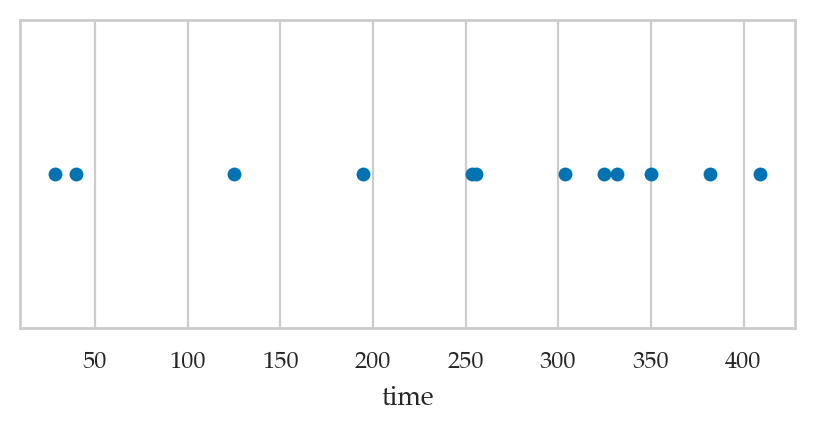

In [39]:
sns.stripplot(data=players, x="time", jitter=0);

We can enhance the strip plot by mapping the `ezlvl` variable to the colour (hue) of the points in the plot.

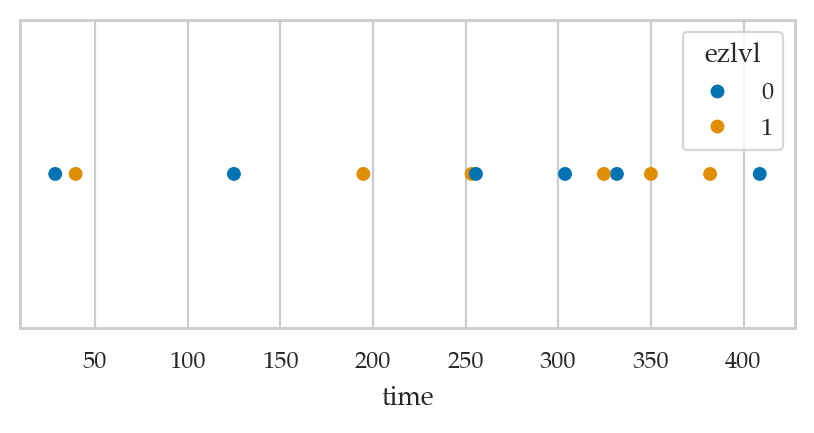

In [40]:
sns.stripplot(data=players, x="time", hue="ezlvl", jitter=0);

### Studying the effect of `ezlvl` on `time`

The players dataset was collected as part of an experiment
designed to answer the question "Does the easy first level lead to an improvement in user retention?"
We want to compare the `time` variable (total time players spent in the game)
of players who were shown the "easy level" version of the game (`ezlvl==1`)
to the control group of played who played the regular vesion of the game (`ezlvl==0`).

The mean `time` in the intervention group is:

In [41]:
mean1 = players[players["ezlvl"]==1]["time"].mean()
mean1

257.34166666666664

The mean `time` in the control group is: 

In [42]:
mean0 = players[players["ezlvl"]==0]["time"].mean()
mean0

242.17333333333332

Let's generate a strip plot of the `time` variable for the two groups of players.

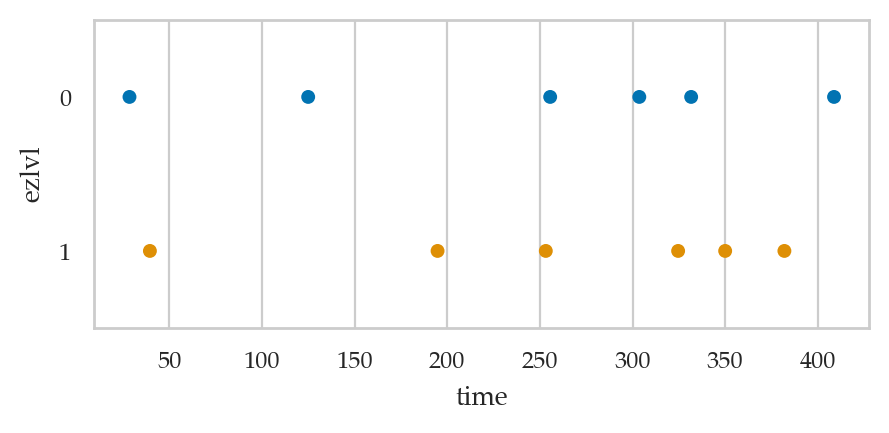

In [43]:
sns.stripplot(data=players, x="time", y="ezlvl",
              hue="ezlvl", orient="h", jitter=0, legend=None);

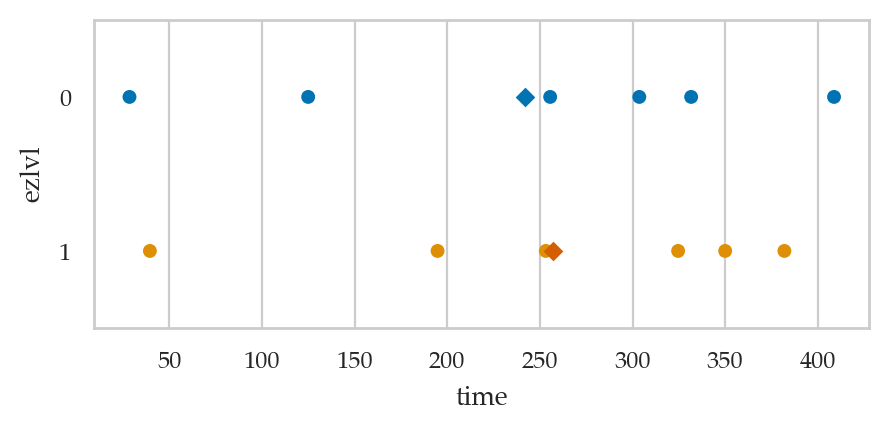

In [44]:
# BONUS. stripplot with diamond `D` markers for the group means
sns.stripplot(data=players, x="time", y="ezlvl",
              hue="ezlvl", orient="h", jitter=0, legend=None)
sns.stripplot(x=[mean0], y=[0], marker="D", orient="h", color="b")
sns.stripplot(x=[mean1], y=[1], marker="D", orient="h", color="r");

### Studying the relationship between `age` and `time`

The secondary research question,
is to look for a correlation between the `age` variable and the `time` variable.

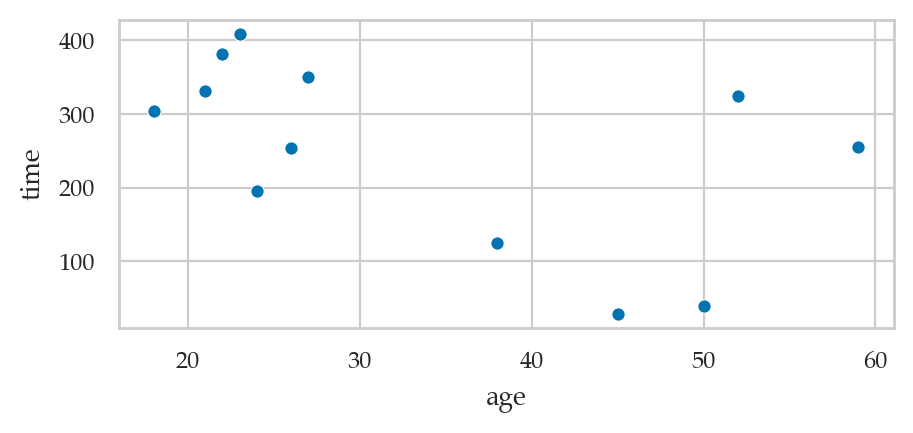

In [45]:
sns.scatterplot(data=players, x="age", y="time");

We can also create a linear regression plot using the `regplot` function.

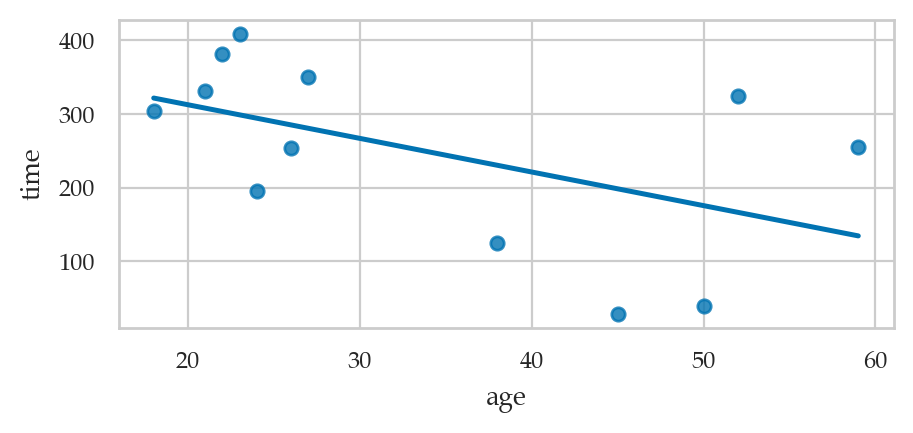

In [46]:
sns.regplot(data=players, x="age", y="time", ci=None);

We'll learn more about linear regression in [Chapter 4](./40_LINEAR_MODELS.md).

## Real-world datasets

Imagine you're a data scientist consulting with various clients.
Clients come to you with datasets and real-world questions they want to answer using statistical analysis.
The following table shows the complete list of the datasets
that we'll use in examples and explanations in the rest of the book.
The last column of the table tells us the sections of the book where each dataset will be discussed.


| index | client name | filename          | shape  | sections           |
|-------|-------------|-------------------|--------|--------------------|
|       |             | `players.csv`     | 12x7   | 1.1, 1.2           |
| 1     | Alice       | `apples.csv`      | 30x1   | 3.1, 3.2           |
| 2     | Bob         | `eprices.csv`     | 18x2   | 3.1, 3.5           |
| 3     | Charlotte   | `students.csv`    | 15x5   | 1.3, 3.1, 3.5, 4.1 |
| 4     | Khalid      | `kombucha.csv`    | 347x2  | 3.1, 3.2, 3.3, 3.4 |
| 5     | Dan         | `doctors.csv`     | 157x12 | 3.1, 3.2, 3.5, 4.1 |
| 6     | Vanessa     | `visitors.csv`    | 2000x3 | 3.6                |
|       |             | `minimal.csv`     | 5x4    | Appendix D         |


Let's briefly describe the background story behind each dataset and state
the statistical question that each client is interested in answering.

### Apple weights

Alice runs an apple orchard.
She collected a sample from the apples harvested this year (the *population*)
and sent you the data in a CSV file called `apples.csv`.

You start by loading the data into Pandas and looking at its characteristics.

In [47]:
apples = pd.read_csv("datasets/apples.csv")
apples.shape

(30, 1)

The first three observations in the apples dataset are:

In [48]:
apples.head(3)

,weight
0,205.0
1,182.0
2,192.0


The sample mean is:

In [49]:
apples['weight'].mean()

202.6

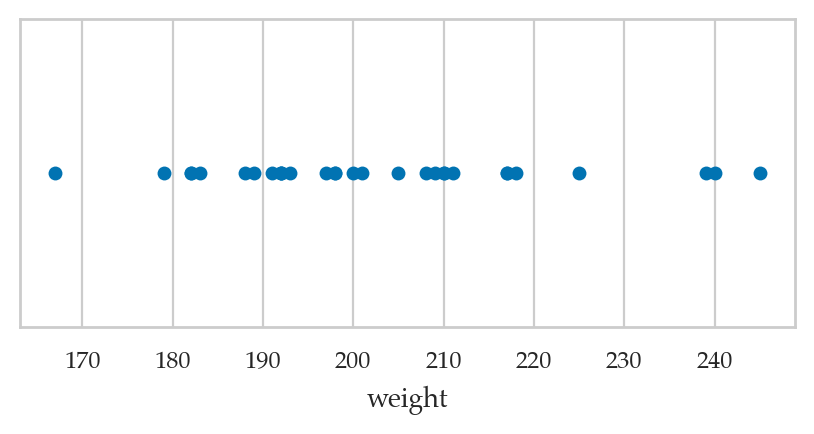

In [50]:
sns.stripplot(data=apples, x="weight", jitter=0);

### Electricity prices

Bob recently bought an electric car.
He doesn't have a charging station for his car at home,
so he goes to public charging stations to recharge the car's batteries.
Bob lives downtown,
so he can go either to the East End or West End of the city for charging.
He wants to know which side of the city has cheaper prices.
Are electricity prices cheaper in the East End or the West End of the city?

To study this question,
Bob collected electricity prices of East End and West End charging stations
from a local price comparison website
and provided you the prices in the dataset `eprices.csv`.

In [51]:
eprices = pd.read_csv("datasets/eprices.csv")
eprices.shape

(18, 2)

The first three observations in the electricity prices dataset are:

In [52]:
eprices.head(3)

,loc,price
0,East,7.7
1,East,5.9
2,East,7.0


The average price in the West End is:

In [53]:
eprices[eprices["loc"]=="West"]["price"].mean()

9.155555555555557

The average price in the East End is:

In [54]:
eprices[eprices["loc"]=="East"]["price"].mean()

6.155555555555556

Let's create a strip plot of electricity prices along the $x$-axis
and use the `loc` variable to control the $y$-position and colour of the points.

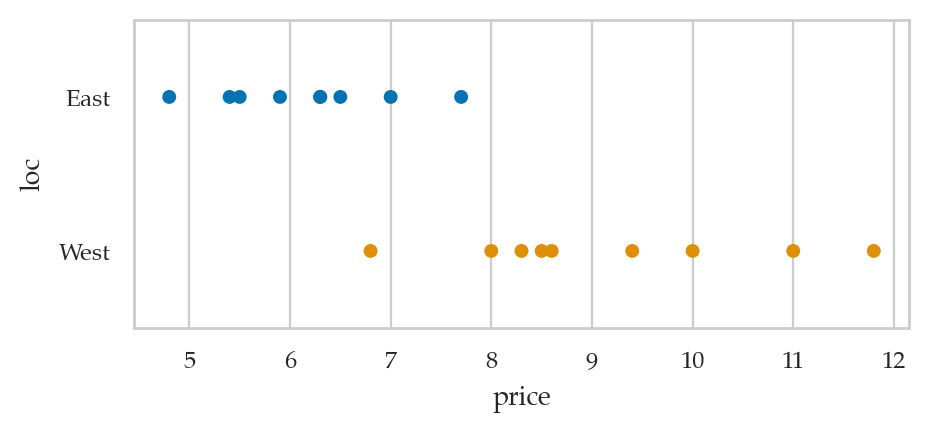

In [55]:
sns.stripplot(data=eprices, x="price", y="loc", hue="loc", jitter=0);

### Students' scores

Charlotte is a science teacher who wants to test the effectiveness of a new teaching method
in which material is presented in the form of a "[scientific debate](https://www.youtube.com/watch?v=eVtCO84MDj8)".
Student actors initially express "wrong" opinions,
which are then corrected by presenting the "correct" way to think about science concepts.
This type of teaching is in contrast to the usual lecture method,
in which the teacher presents only the correct facts.

To compare the effectiveness of the two teaching methods,
she has prepared two variants of her course:

- In the `lecture` variant,
  the video lessons present the material in the usual lecture format
  that includes only correct facts and explanations.

- In the `debate` variant,
  the same material is covered through video lessons
  in which student actors express multiple points of view,
  including common misconceptions.

Except for the different video lessons,
the two variants of the course are identical:
they cover the same topics,
use the same total lecture time,
and test students' knowledge using the same assessment items. 


Let's load the data file `students.csv` into Pandas and see what it looks like.

In [56]:
students = pd.read_csv("datasets/students.csv")
students.shape

(15, 5)

The first five observations in the students dataset are:

In [57]:
students.head(3)

,student_ID,background,curriculum,effort,score
0,1,arts,debate,10.96,75.0
1,2,science,lecture,8.69,75.0
2,3,arts,debate,8.60,67.0


We're interested in comparing the two variants of the course,
so we can generate a strip plot of the `score` variable,
for the two groups defined by the `curriculum` variable.

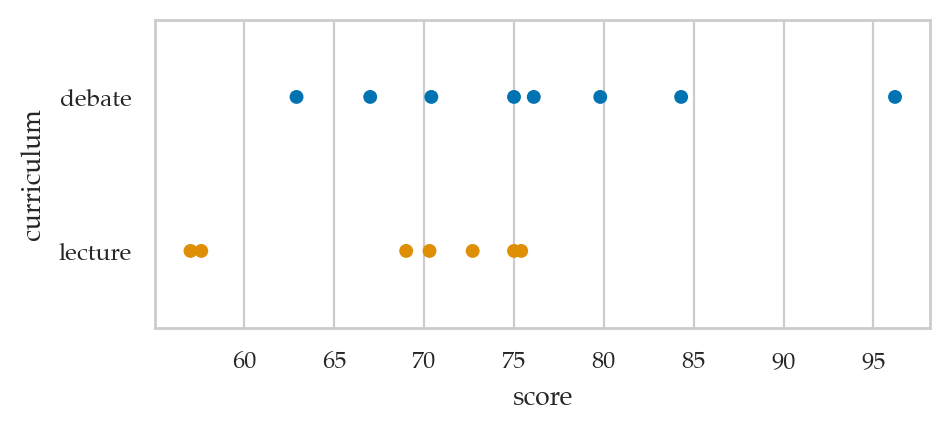

In [58]:
sns.stripplot(data=students, x="score",
              y="curriculum", hue="curriculum", jitter=0);

In [59]:
lstudents = students[students["curriculum"]=="lecture"]
lstudents["score"].mean()

68.14285714285714

In [60]:
dstudents = students[students["curriculum"]=="debate"]
dstudents["score"].mean()

76.4625

### Kombucha volumes

Khalid is responsible for the production line at a kombucha brewing company.
He needs to make sure the volume of kombucha that goes into each bottle is exactly 1 litre (1000 ml),
but because of day-to-day variations in the fermentation process,
production batches may end up with under-filled or over-filled bottles.
Sending such *irregular* batches to clients will cause problems for the company,
so Khalid wants to find a way to detect when the brewing and bottling process is not working as expected.

Khalid compiled the dataset `kombucha.csv`,
which contains the volume measurements from samples taken from 10 different production batches,

In [61]:
kombucha = pd.read_csv("datasets/kombucha.csv")
kombucha.shape

(347, 2)

In [62]:
kombucha.columns

Index(['batch', 'volume'], dtype='str')

The first three observations in the kombucha dataset are:

In [63]:
kombucha.head(3)

,batch,volume
0,1,1016.24
1,1,993.88
2,1,994.72


Let's generate a combined strip plot of the observations from the different batches
so that we can visually inspect the data.

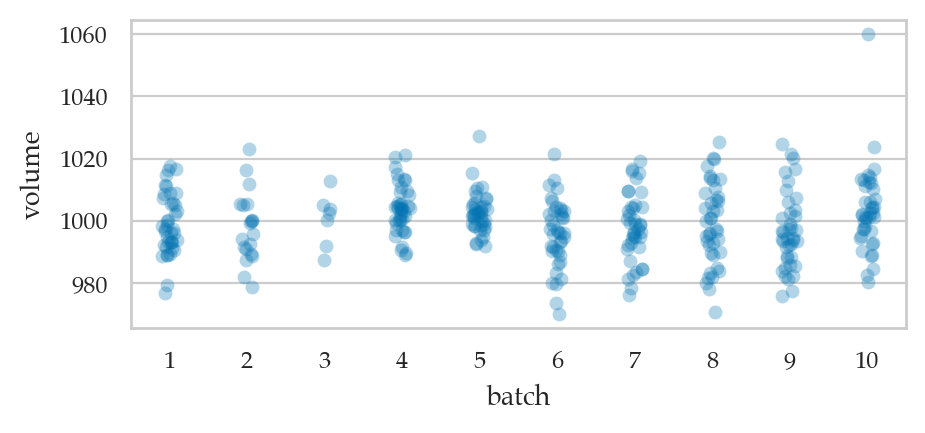

In [64]:
sns.stripplot(data=kombucha, x="batch", y="volume", alpha=0.3);

#### Average volume of the sample from Batch 01

In [65]:
batch01 = kombucha[kombucha["batch"]==1]
ksample01 = batch01["volume"]
ksample01.mean()

999.10375

### Doctors' sleep study

Dan is a data analyst working at the Ministry of Health.
His current assignment is to look for ways to improve the health of family doctors.
He collected the doctors dataset (`doctors.csv`),
which contains data about the demographics, life habits, and health metrics
of 224 family doctors that Dan randomly selected from the populations of family doctors in the country.

In [66]:
doctors = pd.read_csv("datasets/doctors.csv")
doctors.shape

(156, 9)

The first three observations in the doctors dataset are:

In [67]:
doctors.head(3)

,permit,loc,work,hours,caf,alc,weed,exrc,score
0,93273,rur,hos,21,2,0,5.0,0.0,63
1,90852,urb,cli,74,26,20,0.0,4.5,16
2,92744,urb,hos,63,25,1,0.0,7.0,58


Dan is interested in comparing the sleep scores of doctors in rural and urban locations,
so he starts by generating a strip plot of the `score` variable for the two values of the `location` variable.

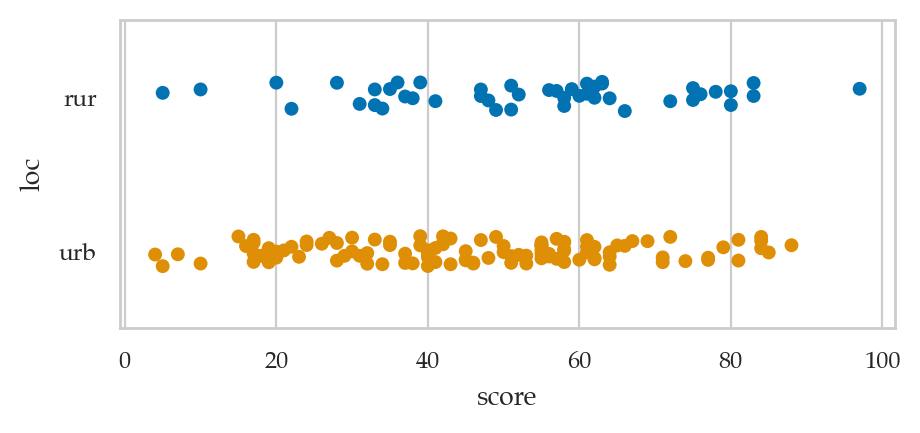

In [68]:
sns.stripplot(data=doctors, x="score", y="loc", hue="loc");

#### Average sleep scores for doctors in different locations

In [69]:
udoctors = doctors[doctors["loc"]=="urb"]
udoctors["score"].mean()

45.96363636363636

In [70]:
rdoctors = doctors[doctors["loc"]=="rur"]
rdoctors["score"].mean()

52.95652173913044

We see doctors in `rur`al locations get better sleep, on average, than doctors in `urb`an locations.

### Website visitors

Vanessa runs an e-commerce website and is about to launch a new design for the homepage.
She wants to know if the new design is better or worse than the current design.
Vanessa has access to the server logs from her website and is able to collect data about
which visitors clicked the BUY NOW button and bought something.
The term *conversion* is used when a visitor buys something,
meaning they are "converted" from visitor to client.
The *conversion rate* is the proportion of website visitors that become clients.

Vanessa performed an experiment to check if the new website design is better than the current design
when it comes to getting visitors to click the BUY NOW button.
For the 2000 new visitors that the site received during the previous month,
Vanessa randomly sent half of them to the new design (A for alternative),
and the other half to the old design (B for baseline).
She also recorded if a visitor bought a product during their visit to the website.

The data consists of 2000 observations from visitors to the website from unique IP addresses.
For each visitor,
the column `version` contains which design they were presented with,
and the column `bought` records whether the visitor purchased something or not.
You use the usual Pandas commands to load the dataset `visitors.csv` to inspect it.

In [71]:
visitors = pd.read_csv("datasets/visitors.csv")
visitors.shape

(2000, 3)

The first five observations in the visitors dataset are:

In [72]:
visitors.head(5)

,IP address,version,bought
0,135.185.92.4,A,0
1,14.75.235.1,A,1
2,50.132.244.139,B,0
3,144.181.130.234,A,0
4,90.92.5.100,B,0


The average (mean) conversion rate for version `A` of the website is:

In [73]:
visitors[visitors["version"]=="A"]["bought"].mean()

0.06482465462274177

The average (mean) conversion rate for version `B` of the website is:

In [74]:
visitors[visitors["version"]=="B"]["bought"].mean()

0.03777148253068933

We can represent the two conversion rates using a bar plot.

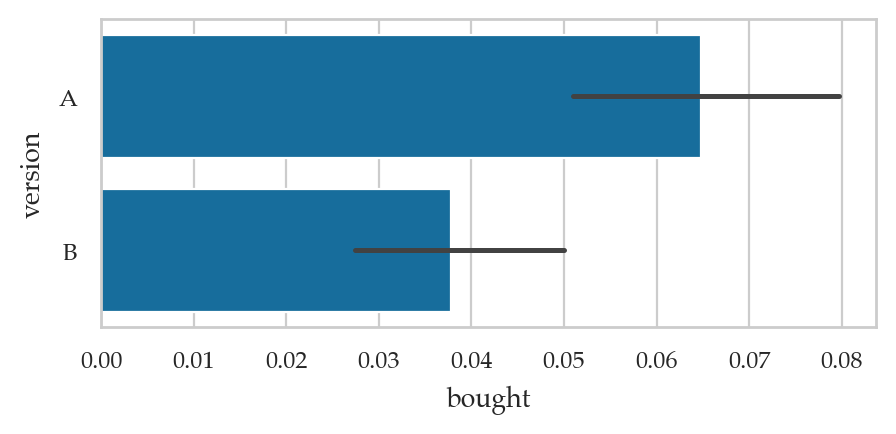

In [75]:
sns.barplot(data=visitors, x="bought", y="version");

The black lines represent the estimates of the uncertainty of the true conversion rates
that Seaborn automatically computed for us.
Specifically,
the black lines represent $95\%$ *confidence intervals* for the true proportions.
We'll learn about confidence intervals later in the book (Section 3.2).

## Explanations

### Using a variable as the index

I want to show you an example of a data frame that uses non-numeric index.
For example,
we can use the players' `username` as the index.

In [76]:
players_by_name = players.set_index("username")
players_by_name

,country,age,ezlvl,time,points,finished
username,,,,,,
mary,us,38,0,124.94,418,0
jane,ca,21,0,331.64,1149,1
emil,fr,52,1,324.61,1321,1
ivan,ca,50,1,39.51,226,0
hasan,tr,26,1,253.19,815,0
jordan,us,45,0,28.49,206,0
sanjay,ca,27,1,350.00,1401,1
lena,uk,23,0,408.76,1745,1
shuo,cn,24,1,194.77,1043,0


In [77]:
# ALT. use the `index_col` option when loading the data
# players2 = pd.read_csv("datasets/players.csv", index_col="username")

The index of the data frame `players_by_name` consists of strings. 
Here are the row-labels we must use to access the data observations.

In [78]:
players_by_name.index

Index(['mary', 'jane', 'emil', 'ivan', 'hasan', 'jordan', 'sanjay', 'lena',
       'shuo', 'r0byn', 'anna', 'joro'],
      dtype='str', name='username')

We can now access players by username.

In [79]:
players_by_name.loc["sanjay"]

country        ca
age            27
ezlvl           1
time        350.0
points       1401
finished        1
Name: sanjay, dtype: object

This examples is to highlight the fact that pandas data frames
are more powerful than spreadsheets,
since we can use arbitrary labels for the rows.

## Discussion

### Data extraction

See [Appendix D: Pandas tutorial](../tutorials/pandas_tutorial.ipynb).

### Data transformations

See [Appendix D: Pandas tutorial](../tutorials/pandas_tutorial.ipynb).

### Tidy data

In [80]:
epriceswide = pd.read_csv("datasets/raw/epriceswide.csv")
epriceswide.shape

(9, 2)

The data frame `epriceswide` is not tidy,
because each row contains multiple observations.

In [81]:
epriceswide

,East,West
0,7.7,11.8
1,5.9,10.0
2,7.0,11.0
3,4.8,8.6
4,6.3,8.3
5,6.3,9.4
6,5.5,8.0
7,5.4,6.8
8,6.5,8.5


We can use the Pandas method `.melt` to convert the `epriceswide` data frame
from "wide" format into "long" format,
with one observation per row.

The method `.melt` takes the argument `var_name`
to specify the name of the variable that is encoded in the column positions,
and the argument `value_name` to specify the name of the variable stored in the individual cells.

In [82]:
epriceswide.melt(var_name="loc", value_name="price")

,loc,price
0,East,7.7
1,East,5.9
2,East,7.0
3,East,4.8
4,East,6.3
5,East,6.3
6,East,5.5
7,East,5.4
8,East,6.5
9,West,11.8


The `.melt` operation transformed the implicit "which column is the data in" information
into an explicit `loc` variable stored in a separate column.
Each row in the transformed data frame contains only a single observation,
so it is in tidy data format.


The melted-`epriceswide` is the same as `eprices` dataset that we saw earlier.
We can confirm this using the `.equals` method.

In [83]:
epriceslong = epriceswide.melt(var_name="loc", value_name="price")
eprices.equals(epriceslong)

True

### Data cleaning

See [Appendix D: Pandas tutorial](../tutorials/pandas_tutorial.ipynb).

## Links


TODO: import from Appendix D